# **CRNN Melhorada**

## Principais características:

1. **Log-Mel Spectrograms** (128 bandas, FFT 2048)
2. **Arquitetura CRNN**: 3 camadas CNN (32, 64, 64) + **LSTM Bidirecional 2 camadas**
3. **Dropout otimizado**: 0.1 nas convolucionais, 0.3 nas densas
4. **Ativação ELU** nas camadas convolucionais
5. **Data augmentation**: Additive Noise, Random Crop, Time Stretching


## Import Libraries


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')


## Parâmetros e Carregamento de Dados

Reutilizamos os dados processados do notebook CNN_Improved (ou processamos novamente se necessário).


In [2]:
SAMPLE_RATE = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

PROCESSED_DIR = "processed_data"

# Tentar carregar dados do CNN_Improved primeiro
spec_file = os.path.join(PROCESSED_DIR, "X_cnn_mel_improved.npy")
labels_file = os.path.join(PROCESSED_DIR, "y_labels_cnn_improved.npy")
folds_file = os.path.join(PROCESSED_DIR, "folds_cnn_improved.npy")

if os.path.exists(spec_file) and os.path.exists(labels_file) and os.path.exists(folds_file):
    print("Carregando dados pré-processados do CNN_Improved...")
    X_crnn = np.load(spec_file)
    y = np.load(labels_file)
    folds = np.load(folds_file)
    print(f"Dados carregados: X shape = {X_crnn.shape}, y shape = {y.shape}")
else:
    print("Dados não encontrados. Execute primeiro o notebook CNN_Improved para processar os dados.")
    raise FileNotFoundError("Execute CNN_Improved.ipynb primeiro para gerar os dados processados.")

n_classes = len(np.unique(y))
print(f"Número de classes: {n_classes}")


Carregando dados pré-processados do CNN_Improved...
Dados carregados: X shape = (34928, 128, 173, 1), y shape = (34928,)
Número de classes: 10


## Arquitetura CRNN

- **CNN**: 3 camadas (32, 64, 64 filtros) com ELU
- **LSTM Bidirecional**: 2 camadas, 64 unidades cada
- **Dropout**: 0.1 nas convolucionais, 0.3 nas densas
- **Pooling**: (3,3), (4,4), (4,4)


In [3]:
def build_crnn_improved_model(input_shape, n_classes, dropout_conv=0.1, dropout_dense=0.3, 
                               lstm_units=64, learning_rate=1e-3, l2_reg=1e-4):
    """
    Constrói CRNN baseada no repositório de referência.
    
    Args:
        input_shape: Shape da entrada (height, width, channels)
        n_classes: Número de classes
        dropout_conv: Dropout nas camadas convolucionais
        dropout_dense: Dropout nas camadas densas
        lstm_units: Número de unidades LSTM
        learning_rate: Taxa de aprendizagem
        l2_reg: Regularização L2
    
    Returns:
        Modelo compilado
    """
    inputs = layers.Input(shape=input_shape)
    
    # ========== BLOCO CNN ==========
    # Conv Block 1: 32 filtros
    x = layers.Conv2D(32, (3, 3), padding='valid',
                      kernel_regularizer=l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D((3, 3))(x)
    x = layers.Dropout(dropout_conv)(x)
    
    # Conv Block 2: 64 filtros
    x = layers.Conv2D(64, (3, 3), padding='valid',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D((4, 4))(x)
    x = layers.Dropout(dropout_conv)(x)
    
    # Conv Block 3: 64 filtros
    x = layers.Conv2D(64, (3, 3), padding='valid',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D((4, 4))(x)
    x = layers.Dropout(dropout_conv)(x)
    
    # ========== RESHAPE PARA RNN ==========
    # Redimensionar para sequência temporal preservando a dimensão temporal
    # Após os 3 blocos de pooling, temos: (batch, freq_reduced, time_reduced, 64)
    # Queremos: (batch, time_steps, features) onde features = freq_reduced * 64
    
    # Usar Lambda para fazer transpose e reshape dinamicamente
    def reshape_for_rnn(x):
        # x shape: (batch, freq, time, channels)
        # Queremos: (batch, time, freq * channels)
        batch_size = tf.shape(x)[0]
        freq_dim = tf.shape(x)[1]
        time_dim = tf.shape(x)[2]
        channels = tf.shape(x)[3]
        
        # Transpose: (batch, time, freq, channels)
        x = tf.transpose(x, [0, 2, 1, 3])
        # Reshape: (batch, time, freq * channels)
        x = tf.reshape(x, [batch_size, time_dim, freq_dim * channels])
        return x
    
    x_reshaped = layers.Lambda(reshape_for_rnn)(x)  # (batch, time_steps, features)
    
    # ========== BLOCO RNN ==========
    # LSTM Bidirecional - 2 camadas (baseado no repositório)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
                                         kernel_regularizer=l2(l2_reg)))(x_reshaped)
    x = layers.Dropout(dropout_conv)(x)
    
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False,
                                         kernel_regularizer=l2(l2_reg)))(x)
    x = layers.Dropout(dropout_conv)(x)
    
    # ========== CLASSIFICADOR ==========
    x = layers.Dropout(dropout_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(n_classes, activation='softmax',
                     kernel_regularizer=l2(l2_reg))(x)
    
    model = models.Model(inputs=inputs, outputs=x)
    
    # Compilar
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Determinar input shape
input_shape = (X_crnn.shape[1], X_crnn.shape[2], X_crnn.shape[3])
print(f"Input shape: {input_shape}")

# Criar modelo
model = build_crnn_improved_model(input_shape, n_classes, lstm_units=64)
model.summary()


Input shape: (128, 173, 1)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 173, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 126, 171, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 126, 171, 32)      128       
 Normalization)                                                  
                                                                 
 elu (ELU)                   (None, 126, 171, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 42, 57, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (No

## Hiperparâmetros e Treino


In [4]:
learning_rate = 1e-3
batch_size = 32
epochs = 50

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

callback_list = [early_stop, reduce_lr]

class_names = ["air-conditioner", "car-horn", "children-playing", "dog-bark", 
               "drilling", "engine-idling", "gun-shot", "jackhammer", 
               "siren", "street-music"]

def plot_graphs(history, y_true, y_pred, class_labels):
    """Visualiza métricas de treino e matriz de confusão"""
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)

    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=axs[2])
    axs[2].set_title('Confusion Matrix')
    axs[2].set_xlabel('Predicted')
    axs[2].set_ylabel('True')
    plt.setp(axs[2].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


## Treino com Validação Cruzada de 10 Folds



=== Training Fold 1 (Validation Fold 2) ===
Train samples: 27884
Validation samples: 3552
Test samples: 3492
Epoch 1/50


872/872 [==============================] - 167s 182ms/step - loss: 1.2091 - accuracy: 0.6090 - val_loss: 1.0460 - val_accuracy: 0.6275 - lr: 0.0010
Epoch 2/50
872/872 [==============================] - 160s 183ms/step - loss: 0.6943 - accuracy: 0.7911 - val_loss: 1.1357 - val_accuracy: 0.7024 - lr: 0.0010
Epoch 3/50
872/872 [==============================] - 153s 176ms/step - loss: 0.5451 - accuracy: 0.8403 - val_loss: 1.2050 - val_accuracy: 0.6582 - lr: 0.0010
Epoch 4/50
872/872 [==============================] - 153s 175ms/step - loss: 0.4519 - accuracy: 0.8730 - val_loss: 0.9944 - val_accuracy: 0.7368 - lr: 0.0010
Epoch 5/50
872/872 [==============================] - 151s 173ms/step - loss: 0.3943 - accuracy: 0.8929 - val_loss: 1.0048 - val_accuracy: 0.7599 - lr: 0.0010
Epoch 6/50
872/872 [==============================] - 151s 173ms/step - loss: 0.3536 - accura

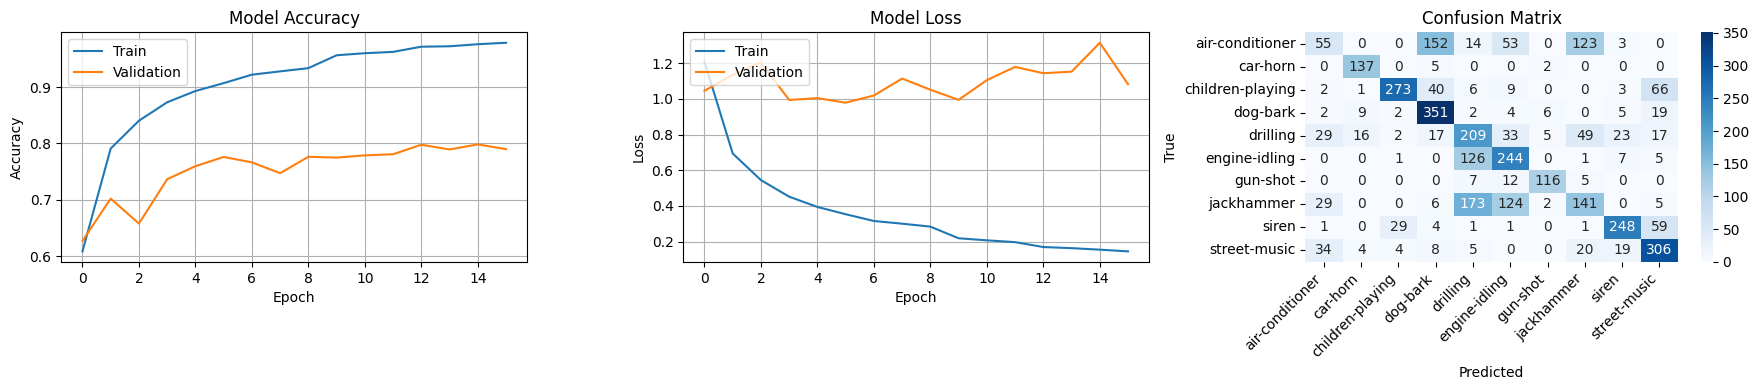


=== Training Fold 2 (Validation Fold 3) ===
Train samples: 27676
Validation samples: 3700
Test samples: 3552
Epoch 1/50
865/865 [==============================] - 151s 166ms/step - loss: 1.1581 - accuracy: 0.6341 - val_loss: 1.6972 - val_accuracy: 0.5603 - lr: 0.0010
Epoch 2/50
865/865 [==============================] - 146s 169ms/step - loss: 0.6505 - accuracy: 0.8076 - val_loss: 1.4738 - val_accuracy: 0.5973 - lr: 0.0010
Epoch 3/50
865/865 [==============================] - 148s 171ms/step - loss: 0.5189 - accuracy: 0.8516 - val_loss: 1.4483 - val_accuracy: 0.6249 - lr: 0.0010
Epoch 4/50
865/865 [==============================] - 146s 169ms/step - loss: 0.4305 - accuracy: 0.8822 - val_loss: 1.5307 - val_accuracy: 0.6238 - lr: 0.0010
Epoch 5/50
865/865 [==============================] - 147s 170ms/step - loss: 0.3733 - accuracy: 0.8988 - val_loss: 1.5259 - val_accuracy: 0.6357 - lr: 0.0010
Epoch 6/50
865/865 [==============================] - ETA: 0s - loss: 0.3363 - accuracy: 0.9143

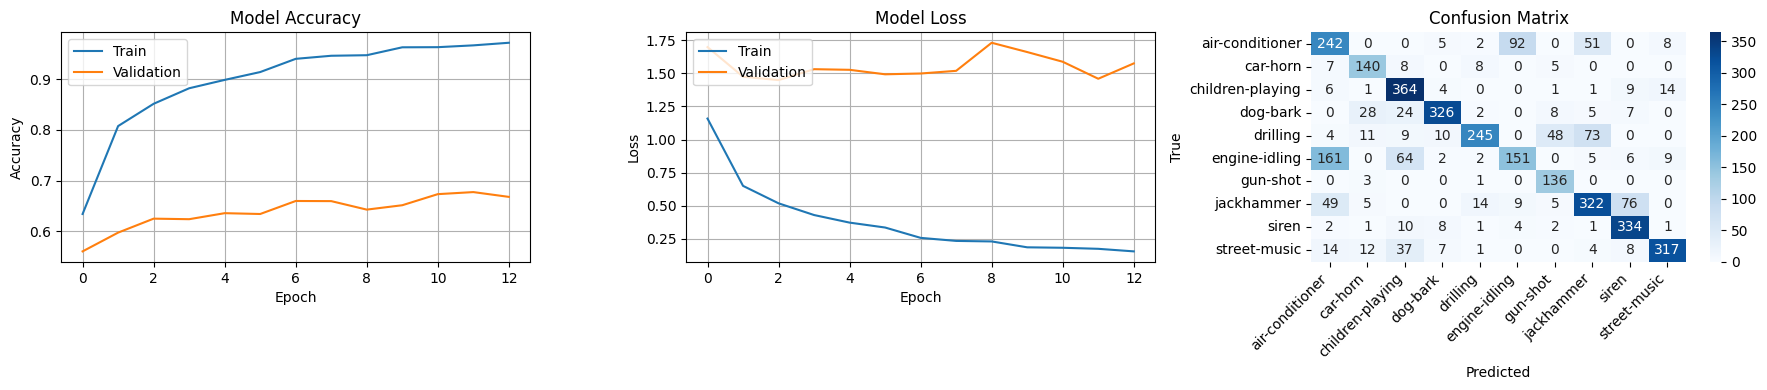


=== Training Fold 3 (Validation Fold 4) ===
Train samples: 27268
Validation samples: 3960
Test samples: 3700
Epoch 1/50
853/853 [==============================] - 150s 167ms/step - loss: 1.1745 - accuracy: 0.6242 - val_loss: 1.3751 - val_accuracy: 0.5586 - lr: 0.0010
Epoch 2/50
853/853 [==============================] - 146s 171ms/step - loss: 0.6757 - accuracy: 0.7971 - val_loss: 1.1317 - val_accuracy: 0.6891 - lr: 0.0010
Epoch 3/50
853/853 [==============================] - 147s 173ms/step - loss: 0.5318 - accuracy: 0.8451 - val_loss: 1.0791 - val_accuracy: 0.6801 - lr: 0.0010
Epoch 4/50
853/853 [==============================] - 150s 176ms/step - loss: 0.4425 - accuracy: 0.8757 - val_loss: 1.2724 - val_accuracy: 0.6699 - lr: 0.0010
Epoch 5/50
853/853 [==============================] - 146s 171ms/step - loss: 0.3866 - accuracy: 0.8955 - val_loss: 0.9448 - val_accuracy: 0.7356 - lr: 0.0010
Epoch 6/50
853/853 [==============================] - 145s 170ms/step - loss: 0.3447 - accuracy

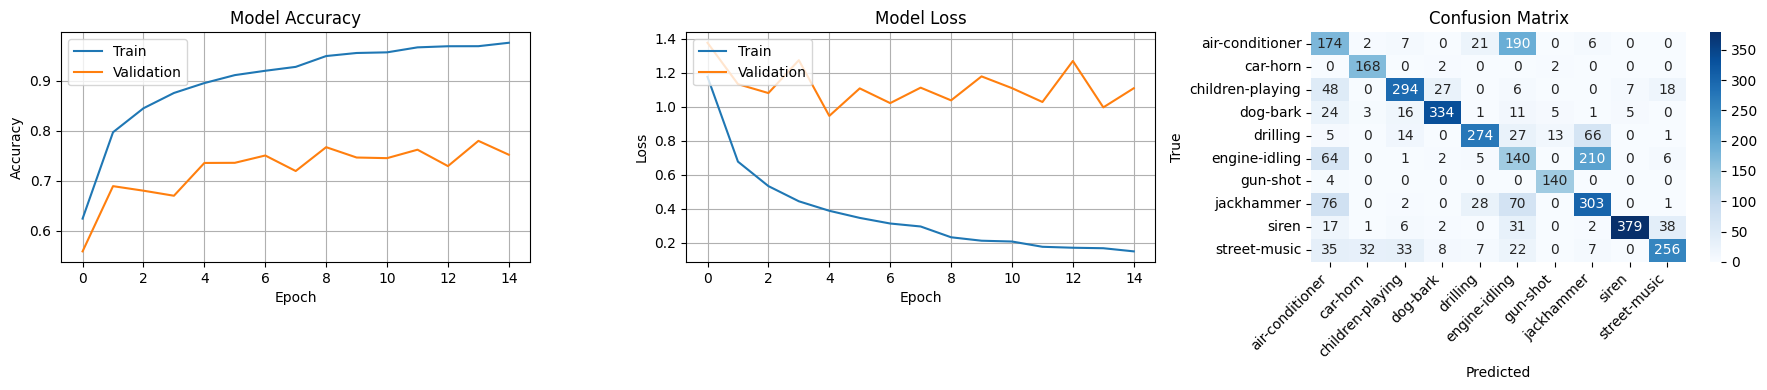


=== Training Fold 4 (Validation Fold 5) ===
Train samples: 27224
Validation samples: 3744
Test samples: 3960
Epoch 1/50
851/851 [==============================] - 156s 174ms/step - loss: 1.2031 - accuracy: 0.6084 - val_loss: 1.1316 - val_accuracy: 0.6784 - lr: 0.0010
Epoch 2/50
851/851 [==============================] - 148s 174ms/step - loss: 0.6923 - accuracy: 0.7894 - val_loss: 0.9922 - val_accuracy: 0.7009 - lr: 0.0010
Epoch 3/50
851/851 [==============================] - 149s 175ms/step - loss: 0.5297 - accuracy: 0.8457 - val_loss: 0.9969 - val_accuracy: 0.7220 - lr: 0.0010
Epoch 4/50
851/851 [==============================] - 145s 171ms/step - loss: 0.4458 - accuracy: 0.8747 - val_loss: 1.0978 - val_accuracy: 0.6955 - lr: 0.0010
Epoch 5/50
851/851 [==============================] - 146s 171ms/step - loss: 0.3866 - accuracy: 0.8945 - val_loss: 0.9264 - val_accuracy: 0.7516 - lr: 0.0010
Epoch 6/50
851/851 [==============================] - 145s 170ms/step - loss: 0.3470 - accuracy

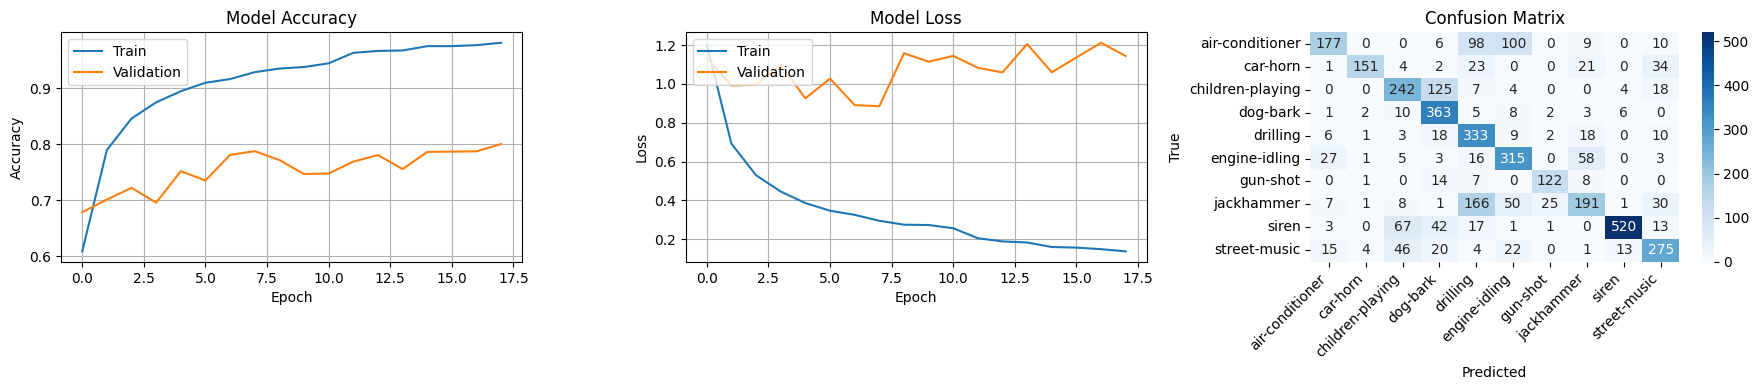


=== Training Fold 5 (Validation Fold 6) ===
Train samples: 27892
Validation samples: 3292
Test samples: 3744
Epoch 1/50
872/872 [==============================] - 161s 175ms/step - loss: 1.2022 - accuracy: 0.6128 - val_loss: 1.2287 - val_accuracy: 0.6324 - lr: 0.0010
Epoch 2/50
872/872 [==============================] - 154s 176ms/step - loss: 0.6773 - accuracy: 0.7955 - val_loss: 1.2323 - val_accuracy: 0.6823 - lr: 0.0010
Epoch 3/50
872/872 [==============================] - 153s 176ms/step - loss: 0.5333 - accuracy: 0.8443 - val_loss: 1.1381 - val_accuracy: 0.7108 - lr: 0.0010
Epoch 4/50
872/872 [==============================] - 152s 174ms/step - loss: 0.4432 - accuracy: 0.8770 - val_loss: 1.3656 - val_accuracy: 0.6455 - lr: 0.0010
Epoch 5/50
872/872 [==============================] - 153s 175ms/step - loss: 0.3907 - accuracy: 0.8939 - val_loss: 1.2064 - val_accuracy: 0.7023 - lr: 0.0010
Epoch 6/50
872/872 [==============================] - ETA: 0s - loss: 0.3512 - accuracy: 0.9068

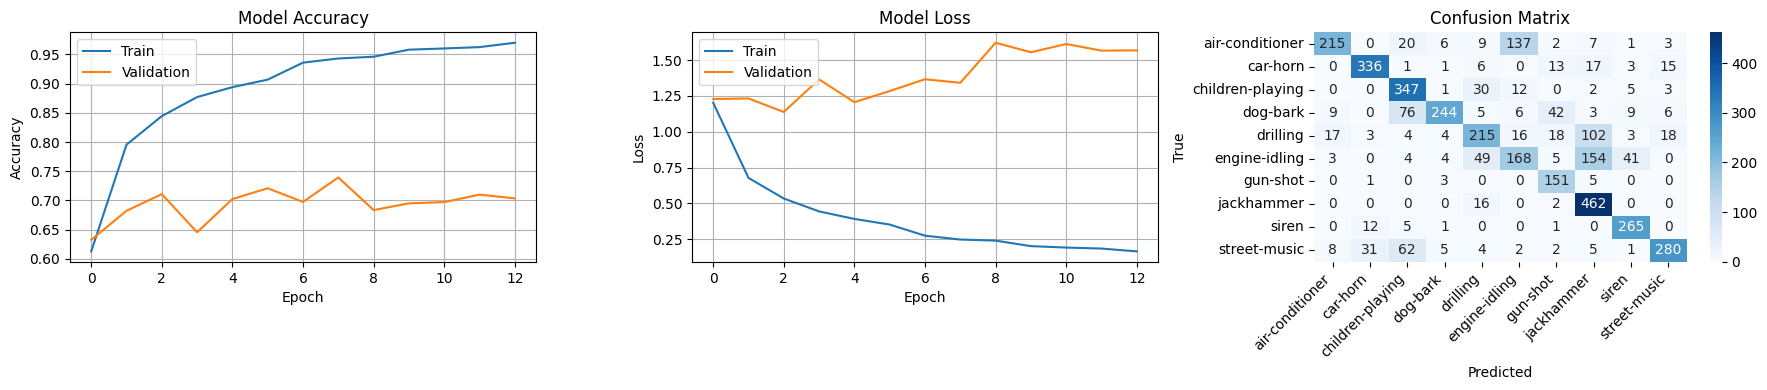


=== Training Fold 6 (Validation Fold 7) ===
Train samples: 28284
Validation samples: 3352
Test samples: 3292
Epoch 1/50
884/884 [==============================] - 161s 174ms/step - loss: 1.1850 - accuracy: 0.6170 - val_loss: 1.2931 - val_accuracy: 0.6229 - lr: 0.0010
Epoch 2/50
884/884 [==============================] - 156s 177ms/step - loss: 0.6643 - accuracy: 0.8003 - val_loss: 1.5403 - val_accuracy: 0.6328 - lr: 0.0010
Epoch 3/50
884/884 [==============================] - 158s 179ms/step - loss: 0.5289 - accuracy: 0.8479 - val_loss: 1.3470 - val_accuracy: 0.6611 - lr: 0.0010
Epoch 4/50
884/884 [==============================] - ETA: 0s - loss: 0.4370 - accuracy: 0.8789
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
884/884 [==============================] - 155s 176ms/step - loss: 0.4370 - accuracy: 0.8789 - val_loss: 1.3848 - val_accuracy: 0.6820 - lr: 0.0010
Epoch 5/50
884/884 [==============================] - 154s 174ms/step - loss: 0.3320 - accura

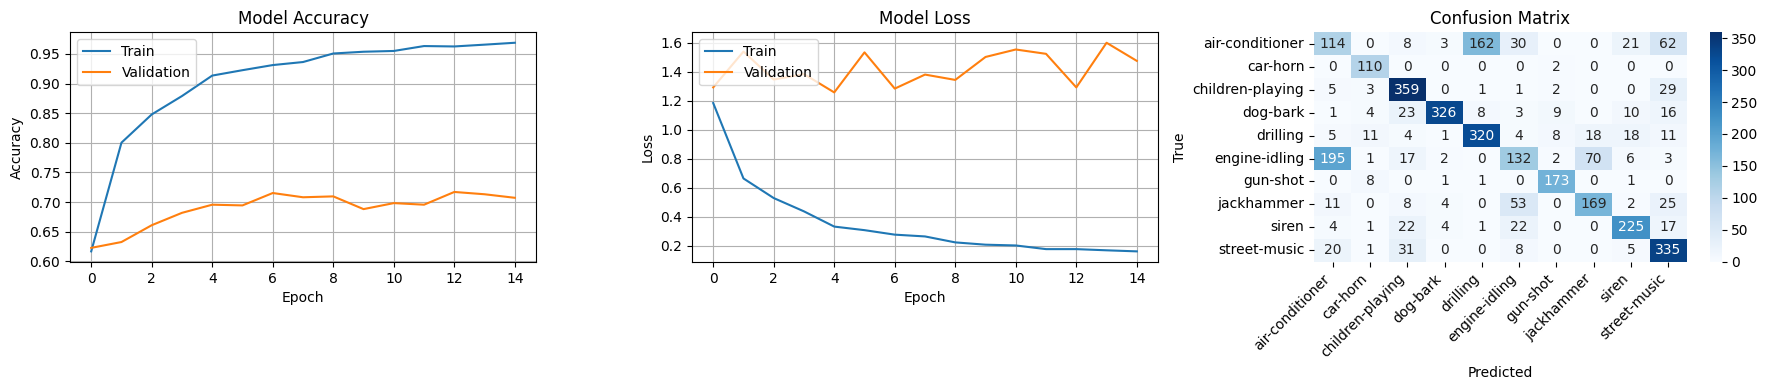


=== Training Fold 7 (Validation Fold 8) ===
Train samples: 28352
Validation samples: 3224
Test samples: 3352
Epoch 1/50
886/886 [==============================] - 143s 151ms/step - loss: 1.1725 - accuracy: 0.6245 - val_loss: 1.3252 - val_accuracy: 0.6160 - lr: 0.0010
Epoch 2/50
886/886 [==============================] - 130s 146ms/step - loss: 0.6680 - accuracy: 0.7979 - val_loss: 1.6053 - val_accuracy: 0.6486 - lr: 0.0010
Epoch 3/50
886/886 [==============================] - 128s 145ms/step - loss: 0.5244 - accuracy: 0.8499 - val_loss: 1.3958 - val_accuracy: 0.6771 - lr: 0.0010
Epoch 4/50
886/886 [==============================] - ETA: 0s - loss: 0.4427 - accuracy: 0.8763
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
886/886 [==============================] - 137s 155ms/step - loss: 0.4427 - accuracy: 0.8763 - val_loss: 1.6732 - val_accuracy: 0.6582 - lr: 0.0010
Epoch 5/50
886/886 [==============================] - 135s 152ms/step - loss: 0.3393 - accura

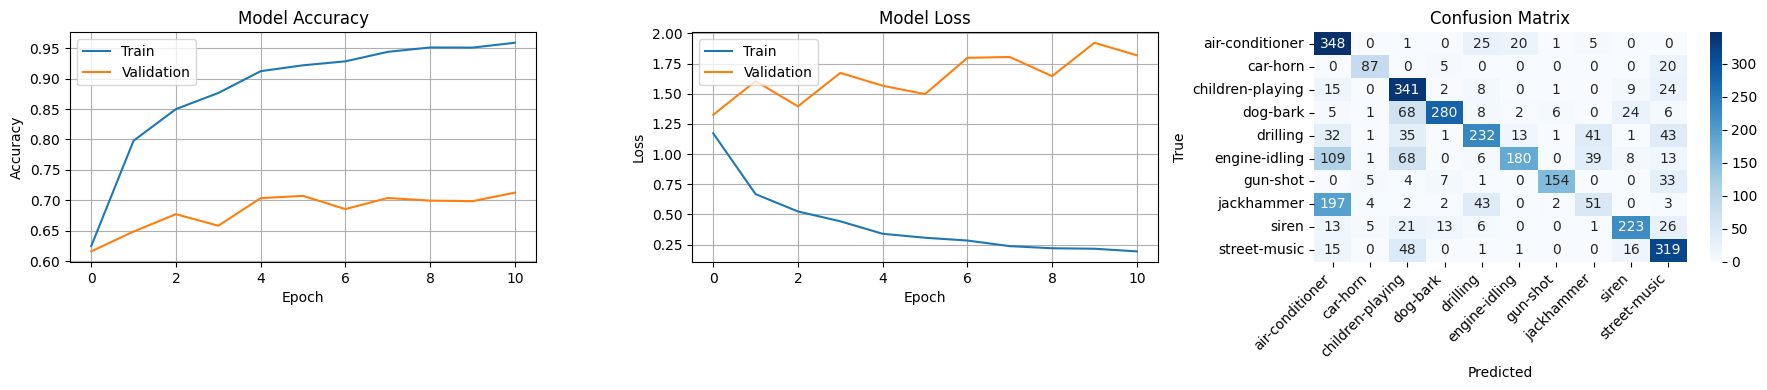


=== Training Fold 8 (Validation Fold 9) ===
Train samples: 28440
Validation samples: 3264
Test samples: 3224
Epoch 1/50
889/889 [==============================] - 141s 149ms/step - loss: 1.1728 - accuracy: 0.6235 - val_loss: 1.1669 - val_accuracy: 0.6385 - lr: 0.0010
Epoch 2/50
889/889 [==============================] - 135s 152ms/step - loss: 0.6473 - accuracy: 0.8051 - val_loss: 1.2254 - val_accuracy: 0.7086 - lr: 0.0010
Epoch 3/50
889/889 [==============================] - 137s 154ms/step - loss: 0.5032 - accuracy: 0.8546 - val_loss: 1.2697 - val_accuracy: 0.6967 - lr: 0.0010
Epoch 4/50
889/889 [==============================] - ETA: 0s - loss: 0.4288 - accuracy: 0.8805
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
889/889 [==============================] - 131s 148ms/step - loss: 0.4288 - accuracy: 0.8805 - val_loss: 1.2850 - val_accuracy: 0.7157 - lr: 0.0010
Epoch 5/50
889/889 [==============================] - 132s 149ms/step - loss: 0.3242 - accura

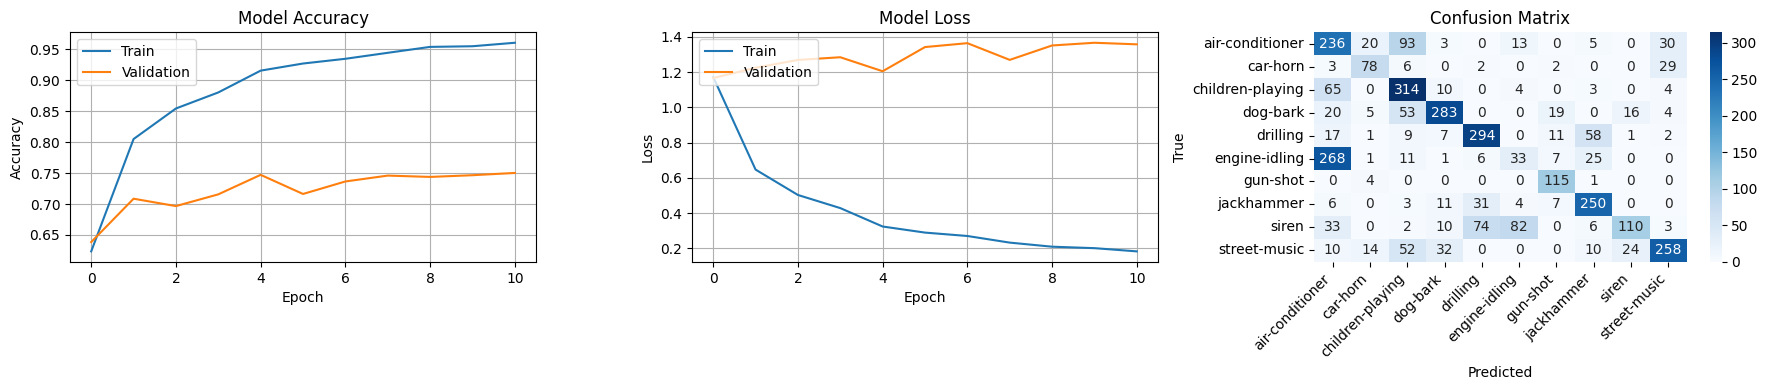


=== Training Fold 9 (Validation Fold 10) ===
Train samples: 28316
Validation samples: 3348
Test samples: 3264
Epoch 1/50
885/885 [==============================] - 140s 148ms/step - loss: 1.1882 - accuracy: 0.6146 - val_loss: 0.9720 - val_accuracy: 0.7180 - lr: 0.0010
Epoch 2/50
885/885 [==============================] - 135s 152ms/step - loss: 0.6818 - accuracy: 0.7949 - val_loss: 1.2237 - val_accuracy: 0.6777 - lr: 0.0010
Epoch 3/50
885/885 [==============================] - 131s 148ms/step - loss: 0.5303 - accuracy: 0.8458 - val_loss: 0.8934 - val_accuracy: 0.7509 - lr: 0.0010
Epoch 4/50
885/885 [==============================] - 130s 147ms/step - loss: 0.4438 - accuracy: 0.8770 - val_loss: 0.8600 - val_accuracy: 0.7625 - lr: 0.0010
Epoch 5/50
885/885 [==============================] - 131s 148ms/step - loss: 0.3871 - accuracy: 0.8942 - val_loss: 0.9349 - val_accuracy: 0.7685 - lr: 0.0010
Epoch 6/50
885/885 [==============================] - 134s 151ms/step - loss: 0.3494 - accurac

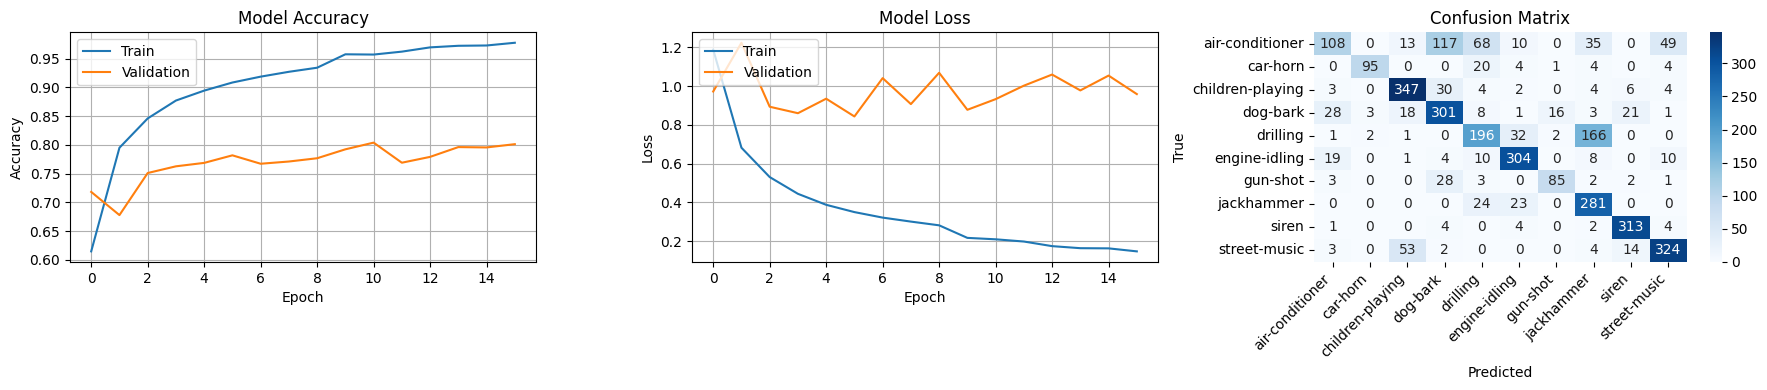


=== Training Fold 10 (Validation Fold 1) ===
Train samples: 28088
Validation samples: 3492
Test samples: 3348
Epoch 1/50
878/878 [==============================] - 146s 156ms/step - loss: 1.1892 - accuracy: 0.6197 - val_loss: 1.5361 - val_accuracy: 0.5398 - lr: 0.0010
Epoch 2/50
878/878 [==============================] - 131s 149ms/step - loss: 0.6905 - accuracy: 0.7916 - val_loss: 1.4463 - val_accuracy: 0.6274 - lr: 0.0010
Epoch 3/50
878/878 [==============================] - 132s 150ms/step - loss: 0.5442 - accuracy: 0.8452 - val_loss: 1.6072 - val_accuracy: 0.6400 - lr: 0.0010
Epoch 4/50
878/878 [==============================] - 132s 150ms/step - loss: 0.4508 - accuracy: 0.8735 - val_loss: 1.7511 - val_accuracy: 0.5845 - lr: 0.0010
Epoch 5/50
878/878 [==============================] - ETA: 0s - loss: 0.3907 - accuracy: 0.8928
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
878/878 [==============================] - 138s 157ms/step - loss: 0.3907 - accur

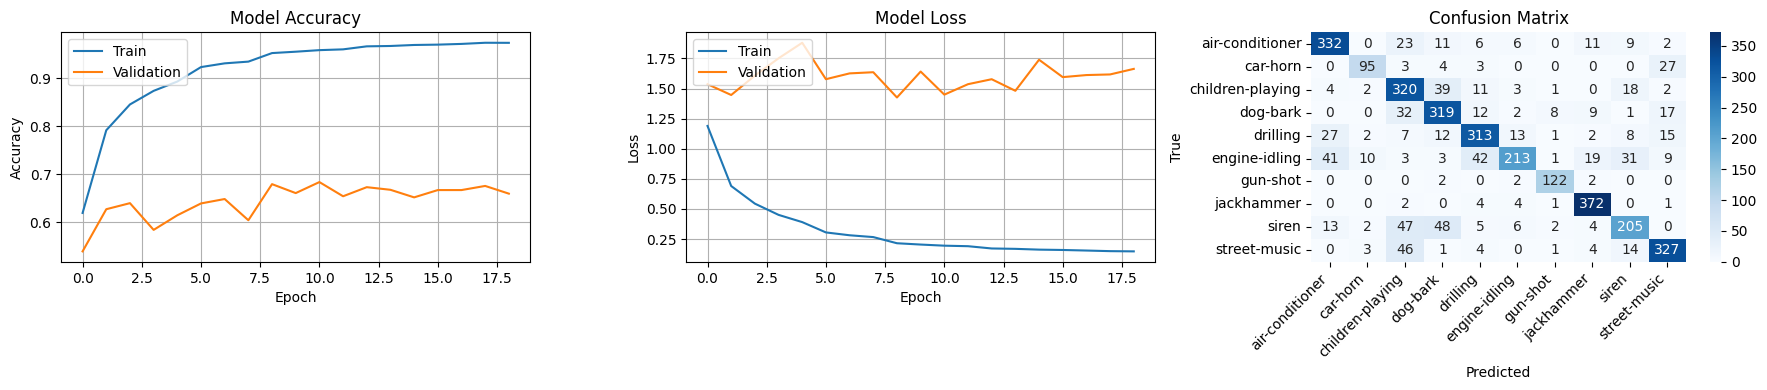


RESULTADOS FINAIS - 10-FOLD CROSS-VALIDATION
Fold accuracies: ['0.5956', '0.7255', '0.6654', '0.6790', '0.7166', '0.6874', '0.6608', '0.6114', '0.7212', '0.7820']
Mean accuracy: 0.6845 ± 0.0527
Target (repositório): 73.5%


In [5]:
# Inicializar variáveis para armazenar resultados
y_true_all = []
y_pred_all = []
conf_mat = np.zeros((n_classes, n_classes), dtype=np.int64)
fold_accuracies = []
fold_histories = []

# 10-fold cross-validation
for test_fold in range(1, 11):
    val_fold = (test_fold % 10) + 1
    
    # Divisão dos dados
    train_idx = np.where((folds != test_fold) & (folds != val_fold))[0]
    val_idx = np.where(folds == val_fold)[0]
    test_idx = np.where(folds == test_fold)[0]
    
    X_train = X_crnn[train_idx]
    X_val = X_crnn[val_idx]
    X_test = X_crnn[test_idx]
    
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]
    
    # Criar modelo
    model = build_crnn_improved_model(
        input_shape=input_shape,
        n_classes=n_classes,
        dropout_conv=0.1,
        dropout_dense=0.3,
        lstm_units=64,
        learning_rate=learning_rate
    )
    
    print(f"\n{'='*60}")
    print(f"=== Training Fold {test_fold} (Validation Fold {val_fold}) ===")
    print(f"{'='*60}")
    print(f"Train samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    
    # Treinar
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callback_list,
        verbose=1
    )
    
    fold_histories.append(history.history)
    
    # Avaliar no conjunto de teste
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    fold_acc = np.mean(y_pred == y_test)
    fold_accuracies.append(fold_acc)
    print(f"\nFold {test_fold} Test Accuracy: {fold_acc:.4f}")
    
    # Atualizar matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
    conf_mat += cm
    
    # Armazenar predições
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())
    
    # Visualizar resultados do fold
    plot_graphs(history, y_test, y_pred, class_names)

# Resultados finais
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\n{'='*60}")
print("RESULTADOS FINAIS - 10-FOLD CROSS-VALIDATION")
print(f"{'='*60}")
print(f"Fold accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")
print(f"Mean accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Target (repositório): 73.5%")
print(f"{'='*60}")


## Matriz de Confusão Global e Métricas por Classe


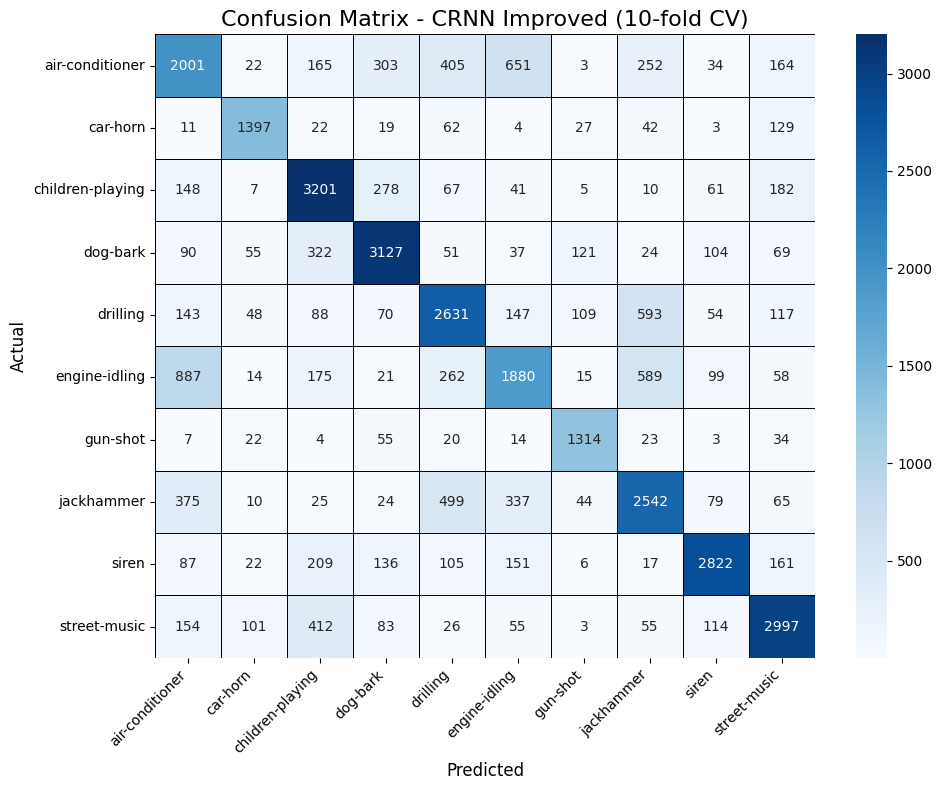


Métricas por Classe:
           Class  Precision   Recall       F1  Support
 air-conditioner   0.512683 0.500250 0.506390     4000
        car-horn   0.822733 0.814103 0.818395     1716
children-playing   0.692408 0.800250 0.742433     4000
        dog-bark   0.759718 0.781750 0.770577     4000
        drilling   0.637355 0.657750 0.647392     4000
   engine-idling   0.566777 0.470000 0.513872     4000
        gun-shot   0.797814 0.878342 0.836144     1496
      jackhammer   0.612973 0.635500 0.624033     4000
           siren   0.836644 0.759419 0.796163     3716
    street-music   0.753773 0.749250 0.751505     4000
   Macro-average   0.699288 0.704661 0.700690    34928

Comparação com repositório:
  Acurácia obtida: 0.68%
  Acurácia repositório: 73.5%
  Diferença: -5.05%


In [6]:
# Matriz de confusão global
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="black"
)
plt.title("Confusion Matrix - CRNN Improved (10-fold CV)", fontsize=16)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Métricas por classe
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    average=None
)

macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

df_metrics.loc[len(df_metrics)] = [
    "Macro-average", 
    macro_precision, 
    macro_recall, 
    macro_f1,
    len(y_true_all)
]

print("\nMétricas por Classe:")
print(df_metrics.to_string(index=False))
print(f"\nComparação com repositório:")
print(f"  Acurácia obtida: {mean_acc:.2f}%")
print(f"  Acurácia repositório: 73.5%")
print(f"  Diferença: {mean_acc*100 - 73.5:.2f}%")


## Curvas de Aprendizagem (Média sobre Folds)

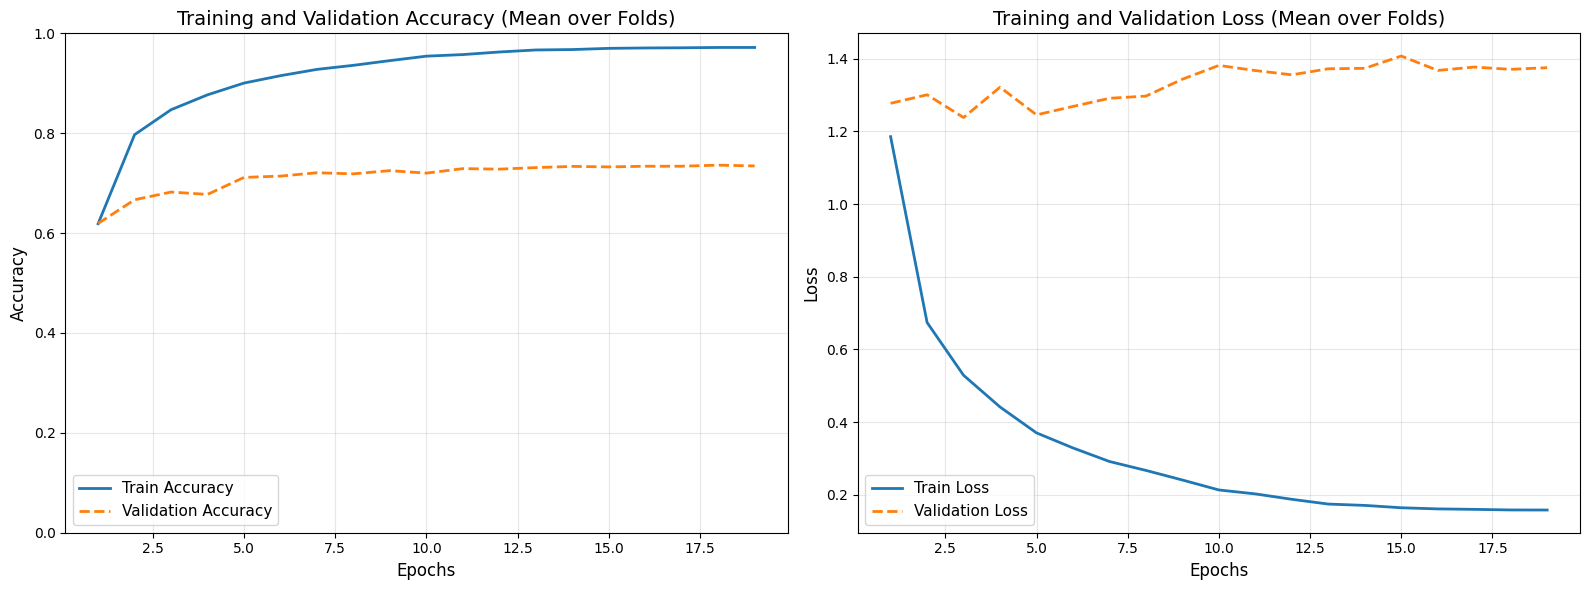

In [7]:
max_epochs = max(len(h["accuracy"]) for h in fold_histories)

def pad(seq, max_len):
    return seq + [seq[-1]] * (max_len - len(seq))

acc_matrix = np.array([pad(h["accuracy"], max_epochs) for h in fold_histories])
val_acc_matrix = np.array([pad(h["val_accuracy"], max_epochs) for h in fold_histories])
loss_matrix = np.array([pad(h["loss"], max_epochs) for h in fold_histories])
val_loss_matrix = np.array([pad(h["val_loss"], max_epochs) for h in fold_histories])

mean_acc_curve = np.mean(acc_matrix, axis=0)
mean_val_acc_curve = np.mean(val_acc_matrix, axis=0)
mean_loss_curve = np.mean(loss_matrix, axis=0)
mean_val_loss_curve = np.mean(val_loss_matrix, axis=0)

epoch_axis = np.arange(1, max_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epoch_axis, mean_acc_curve, label="Train Accuracy", linewidth=2)
ax1.plot(epoch_axis, mean_val_acc_curve, label="Validation Accuracy", linestyle="--", linewidth=2)
ax1.set_title("Training and Validation Accuracy (Mean over Folds)", fontsize=14)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_ylim(0.0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

ax2.plot(epoch_axis, mean_loss_curve, label="Train Loss", linewidth=2)
ax2.plot(epoch_axis, mean_val_loss_curve, label="Validation Loss", linestyle="--", linewidth=2)
ax2.set_title("Training and Validation Loss (Mean over Folds)", fontsize=14)
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()
